Manifold learning methods:

**Isomap:**
- Isomap seeks a lower-dimensional embedding which maintains geodesic distances between all points. (Geodesic distances: shortest path between two points along a surface, as opposed to straight line through space - think of a curved surface like the earth instead of taking just the euclidean straightline distance between two points - we're considering the nature of the orignal surface and taking the geodesic distance instead)
- Isomap starts with a simple observation:
  - Euclidean distances lie, geodesic distances tell the truth
- On a curved manifold, the straightline distance between two points passes through empty space - thru the interior of the swiss roll/earth. it doesn't reflect how far apart points truly are. Isomap: compute the real geodesic distances first then embed...

- Isomap steps: 
  - Build a neieghbor graph: connect each point to its k nearest euclidean neighbors with edges weighted by the euclidean distance
    - Key insight: locally, euclidean distance is a good approximation of geodesic distance (two immediate neighbors are close enough on the manifold that the straight line between them approximately lies on the surface)
  - Compute Geodesic distances:
    - Run Djikstra's shortest path algorithm between every pair of points through the graph. (shortest path from A to B isn't a straightline through space - its a chain of tiny local hops that follows the manifold surface)
        - do this for all pairs where the shortest path from point A to point B isn't a straightline through space but rather its a chain of tiny local hops that follows the manifold surface
        - the sum of all hop distances is the approximate geodesic distance between points A and B
        - So, now we have an nxn geodesic distance matrix D, where D(i,j) reflects the true manifold distance
  - Embed using MDS (Multidimensional Scaling):
    - Feed the matrix D into Multidimensional scaling (MDS) - MDS finds a low dimensional configuration of points that best preserves the distances in D.
      - Concretely:
        - MDS: takes your nxn matrix | finds n points in k dimensional space | minimizes the difference between input distances and output distances
        - min sum(Dij - zij) => z is the distance matrix in lower dimensional space..

- From its philosophy - you can see that Isomap looks at global distance preservation unlike methods like lle which consider local relationships
- Also preserves geodesic distances unlike lle that uses euclidean distances for finding neighbors
- global struct is preserved...
- Isomap: top down approach... compute global geodesic distances, then find an embedding that respects them all
- LLE: bottom up approach ... get local relationships right everywhere, hope the global structure emerges correctly

- Isomap fails when:
  - data is noisy: noise creates shortcut edges in the neighbor graph, corrupting geodesic paths
  - manifold has holes or an irregular topology: shortest paths go around holes incorrectly
  - data is sparse: neighbor graph becomes disconnected, geodesic distances undefined between components..


sklearn isomap api:
- n_neighbors: controls how many nearest neighbors each point connects to initially, (euclidean dist matrix from which geodesic distances are computed)
  - too small - results in a sparse graph (euclidean graph) | geodesic paths are forced through few routes | noise or missing data can disconnect the graph entirely - geodesic distances become undefined between disconnected components and the algo fails
    - local euclidean hops are very short and accurate approximations of geodesic distances is good
    - extreme case: graph breaks into islands and sklearn throws an error

  - too large: graph is dense - points connect to many neighbors including some far away. Short edges then appear and points on the opposite sides of the manifold then become neighbors.
    - geodesic paths now take shortcuts through space rather than following the surface
    - manifold effectively gets collapsed - geodesic distances undersestimate true manifold distances

  - n_components: target dimensionality => controls the number of dimensions that MDS reduces to
  - metric and p: controls step 1- what distance metric is used to find the k nearest neighbors and build the connection graph...default is minkowski with p=2  which is standard euclidean. (remember from the explanation, isomap uses euclidean distance only for local hops. the assumption is that locally, euclidean distances approximates geodesic distances. This assumption holds best when features are on similar scales and euclidean distance is meaningful.)
   - minkowshi/Manhattan distance, metric = 'minkowski' or p=1 is more robust to outliers in high dimensional data
   - metric = 'cosine' => better for text/sparse high dimensional data
   - can also define your own custom fn...

  - path_method: controls how geodesic distances are computed: 
    - Floyd-Warshall: 'FW' => computes all pairs shortest paths simultaneously | time complexity: O(n3) slow for large n | memory O
    - Djikstra 'D' => computes shortest path from each node one at a time.. better for large n with small n_neighbors. 
    - 'auto' -> picks djikstra for sparse graphs and floyd for dense ones

  - neighbors_algorithm: how nearest neighbors are found : algo to find nearest neighbors.. can use 'auto'
  - eigen_solver : MDS solver: can use 'auto'

In [1]:
from sklearn.datasets import make_swiss_roll
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

In [2]:
from sklearn.manifold import Isomap

In [37]:
iso = Isomap(n_neighbors=10, n_components=2)

In [38]:
x_transformed = iso.fit_transform(X_swiss)

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

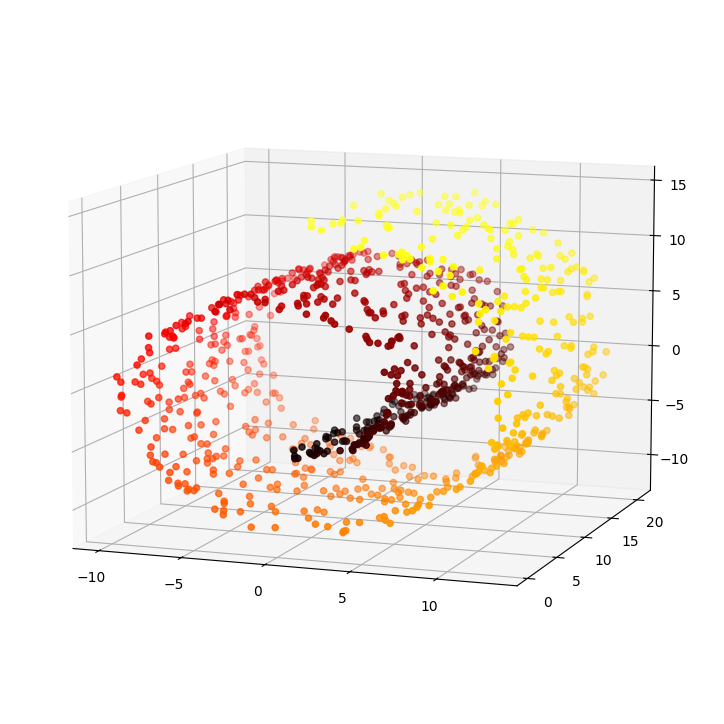

In [26]:
darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))



fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(121, projection='3d')

ax1.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=t, cmap=darker_hot)
ax1.view_init(10, -70)
plt.show()

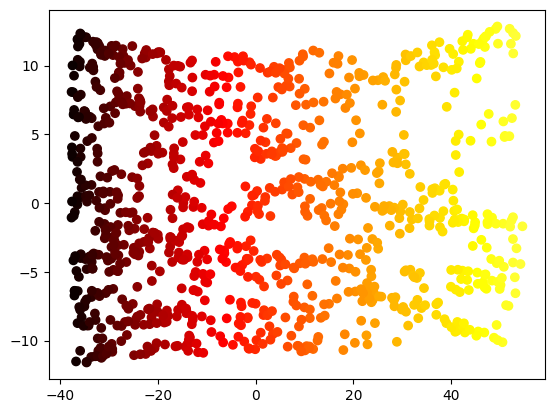

In [39]:
fig, ax = plt.subplots()
ax.scatter(x_transformed[:,0], x_transformed[:,1], c=t, cmap=darker_hot)

key hyperparams is number of neighbors:
- increasing it makes the graph more filled but shouldn't be increased to a high number as you risk having edge shortcuts
- low value makes the graph sparse...
- n_neighbors: 5-safe for clean data | 10 is a good general starting point | 20 for denser data needs more neighbors..

In [40]:
from sklearn.decomposition import KernelPCA

In [67]:
kpca = KernelPCA(n_components=2, kernel='rbf')

In [68]:
x2 = kpca.fit_transform(X_swiss)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


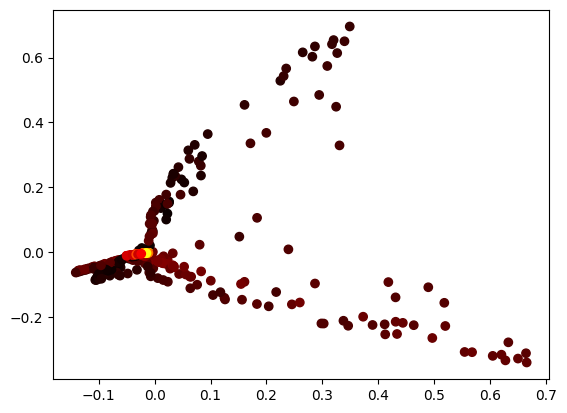

In [69]:
fig, ax = plt.subplots()
ax.scatter(x2[:,0], x2[:,1], c=t, cmap=darker_hot)

In [47]:
from sklearn.decomposition import PCA

In [58]:
pca = PCA(n_components=2)

In [59]:
x3 = pca.fit_transform(X_swiss)

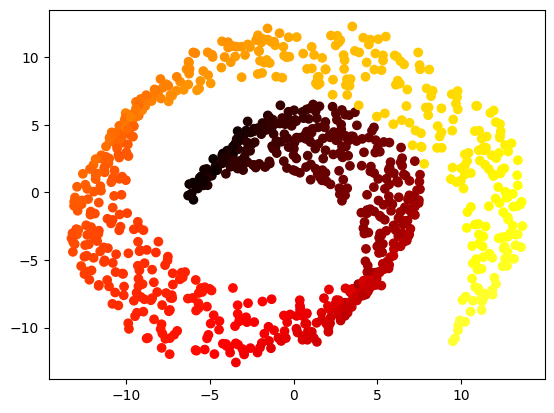

In [60]:
fig, ax = plt.subplots()
ax.scatter(x3[:,0], x3[:,1], c=t, cmap=darker_hot)

Multidimensional Scaling: MDS
- **Core idea of multidimensional scaling:**
  - MDS starts with a distance matrix D - an nxn matrix where D(i,j) is how far a part point i and point j are. 
  - Question MDS asks is : Given only pairwise distances between points, find coordinates in k dimensions that reproduce those distances as faithfully as possible
  - give it distances and then get coordinates. finds coordinates in a lower dimensional space such that the euclidean distances in the lower dim space match those in the higher dim one..

Math operation:
- **Step 1 - Start with distance matrix D**
    - D is nxn, D(i,j) = distance between point i and point j. (symmetric, zeros on diagonal)
    - The distance can be anything - euclidean, geodesic (isomap), correlation based, domain specific. MDS doesn't care where the distances come from
- **Step 2 - Convert the distances to dot products (double centering)**
    - MDS needs to find coordinates Z such that the distances are preserved. it turns out this is equivalent to finding Z such that the gram matrix ZZt matches a transformed version of D. The transformation is double centering:
    - Essentially in simple terms in this step, we convert the original pairwise distances matrix into something you can eigendecompose
- **Step 3 - Eigendecompose the matrix**
   - find the top k eigen vectors and eigenvalues
- **Step 4 - Recover coordinates**
   - use the eigenvectors and eigenvalues to compute a low dimensional coordinate matrix...

- Classical MDS described above is exactly like PCA if you feed it euclidean distances from a feature matrix. (assumes distances are euclidean, uses eigendecomposition, if distances are truly euclidean then reconstruction is perfect)

- Metric MDS - distances do not have to be euclidean - any meaningful distance works | minimizes stress (a measure of how poorly the embedding reproduces distances) | is solved iteratively - no closed form solution 

- Nonmetric MDS - doesn't even try to reproduce exact distances | only tries to preserve the rank ordering of distances - if A is closer to B than C is to D in the original space, it should still be closer in th embedding | most flexible and works when distances are ordinal (you know the relative ordering but not exact values) | also minimizes a stress function but on rank not values

- **The PCA Connection**
  - Classical MDS with euclidean distsnces is mathematically identical to pca. 

- Note also that Geodesic distances + MDS = isomap
- **MDS finds a low dimensional coordinate matrix Z where the pairwise distances between points in Z match the pairwise distances in the original space as closely as possible.**

In [70]:
from sklearn.manifold import MDS

In [71]:
mds = MDS(
    n_components=2,
    metric=True,
    n_init=4,
    max_iter=300,
    eps=1e-3,
    n_jobs=None,
    random_state=42,
    dissimilarity='euclidean'
)

- dissimilarity => most important parameter 
  - 'euclidean' - sklearn computes eucludean distances from your feature matrix X
  - 'precomputed' - u pass your own distance matrix directly. this is where MDS' flexibility lives - can pass any distance matrix you want...

In [72]:
# using precomputed distances
from sklearn.metrics import pairwise_distances

In [73]:
X_swiss.shape

(1000, 3)

In [95]:
D = pairwise_distances(X_swiss, metric='cosine')

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [96]:
D.shape

(1000, 1000)

In [97]:
X = MDS(n_components=2, metric=True, n_init=4, max_iter=300, eps=1e-3, n_jobs=None, random_state=42, dissimilarity='precomputed').fit_transform(D)

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=True instead of metric=True. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(
/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encount

In [98]:
X.shape

(1000, 2)

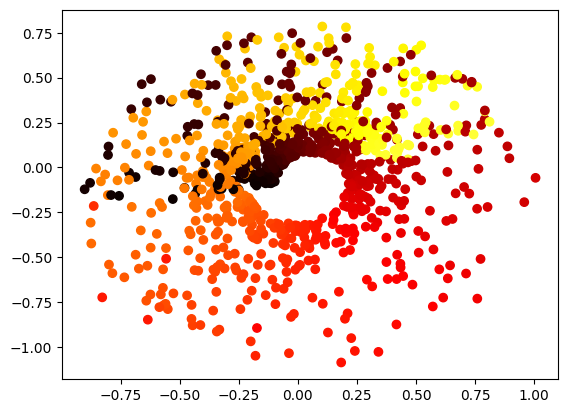

In [99]:
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], c=t, cmap=darker_hot)

spectral embedding:
- core idea:
  - if you were to diffuse information across the data like heat spreading through a material, which points would naturally end up in the same region?
  - points that are strongly connected - many short paths between them - heat up together quickly. points that are weakly connected - sparse paths, long routes - stay thermally isolated. the embedding finds coordinates that reflect this connectivity structure.
  - this is why its called spectral - it uses the eigenspectrum (eigenvectors) of a matrix that encodes the graph connectivity of your data.

- **Building Intuition - The Graph View:**
  - every dataset can be viewed as a graph. points are nodes. similar points are connected by edges. the strength of connection reflects summary
  - from the graph connectivity structure spectral embedding finds points connected to each other....| studies and comes up with the structure....

- **The five steps:**
 - Step 1: Build a similarity graph
   - connect each point to its k nearest neighbors (or all points within a radius epsilon). weight each edge by similarity - closer points get higher weight.
   - most common weighting - RBF/Gaussian | this gives you a weighted adjacency matrix W of shape (nxn). High W(i,j), means points i and j are strongly connected. zero means not connected...

 - Step 2: Compute the degree matrix:
   - the degree of each node is the sum of its edge weights - how strongly connected it is overall... D is a diagonal matrix - zeros everywhere except the diagonal.. Dii = sum(Wij) for all js connected to i. 

 - Step 3: Compute the Graph Laplacian:
   - this is the heart of spectral embedding - The graph Laplacian is: L = D - W | 
   - the laplacian encodes the connectivity structure of the graph. Its mathematical properties directly reflect the cluster structure...
     - Laplacian is always positive and semidefinite
     - Number of zero eigenvalues = number of disconnected points
     - small eigenvalues correspond to smooth, slowly varying functions on the graph
 
 - Step 4: Eigendecompose the Laplacian
   - find the k eigenvectors corresponding to the **smallest non-zero eigenvalues**. Not the largest like PCA - but the smallest..
   - Smallest because small eigenvectors correspond to the smoothest variations across the graph - directions where strongly connected points move together. these are the directions that best reflect the cluster structure..
   - The very smallest eigenvalue is always zero (constant vector - trivial solution, discarded) - you take the eigenvectors 2 through k+1...

 - Step 5: Use eigenvectors as embedding coordinates
   - stack the k eigenvectors as columns:
     - Z = [v2, v3, ..., vk+1] | shape: (nxk)
     - each row of Z is the low dimensional embedding of the corresponding point...
     Z is the low dimensional embedding of the corresponding point......


- The full picture in one flow:
  - X (n x p) => Build similarity graph W (nxn) => Compute Laplacian L = D - W (n x n) => Eigendecompose L -> n eigenvectors, n eigenvalues => sort by eigenvalue (smallest to the largest) => discard v1 (trivial constant vector) => take the next k eigenvectors: v2....v_{k+1} => resultant matrix Z = [v2 | v3 | ..... | v_{k+1}] - is of shape (n x k)
  - Z is the final result...

  - why take the smallest eigenvectors that correspond to smallest variance....
    - (opposite of PCA)
      - PCA takes eigenvectors of the covariance matrix corresponding to the largest eigenvalues - directions of maximum variance...
      - Spectral embedding on the other hand takes eigenvectors of the laplacian corresponding to the smallest non-zero eigenvalues - directions of maximum smoothness across the graph...
      - the reason is what each method is optimising for...
        - PCA wants maximum spread - large eigenvalues = large variance
        - Spectral embedding wamts maximum smoothness - smallest eigenvalues = slowly varying signals = cluster respecting directions..

        - What each column of Z represents:
          - each col of Z is one eigenvector - one smooth signal defined over all n points:
            - points in the same cluster get similar values across all k cols

 - why eigenvectors of the laplacian give you clusters:
   - this is the key insight. The graph laplacian has a beautiful property.
     - the eigenvector correspoding to the second smallest eigenvalue (called the Fiedler vector) is the smoothest non-trivial function on the graph. it assigns values to nodes such that:
       - connected nodes get similar values
       - the function varies as smoothly as possible across edges


 - we don't mul the final Z with the original matrix cuz.... in PCA - the eigendecomposition is of the covariance matrix (feature space). In Spectral embedding - the eigendecomposition is of the Laplacian matrix... (nxn) matrix which lives in the sample space...



 - Why Eigenvectors of the laplacian give you clusters:
   - This is the key insight. The graph laplacian has a beautiful property..
     - the eigenvector, corresponding to the second smallest eigenvalue (called the Fiedler vector) - is the smoothest non-trivial function on the graph. it assigns values to nodes such that: connected nodes get similar values | the function varies as smoothly as possible across the edges..

     - For a graph with 2 clusters and a weak bridge between them....
       - Cluster A nodes: Fiedler vector values: approx equal to: -0.3, -0.3, -0.2, -0.3
       - Cluster B nodes: Fiedler vector values: approx equal to: +0.3, +0.2, +0.3, +0.3
    
       - From above can be seen that the value across feature space for both nodes is different...this is due to the fiedler vector which is maximizing for smoothness from the original laplacian matrix so that shows that the two nodes were as far apart as they could have been.

       - this is why **spectral clustering is literally just spectral embedding followed by k-means**. => the eigenvectors already separate the clusters, k-means just formalizes it.

**Spectral Embedding:**

In [100]:
from sklearn.manifold import SpectralEmbedding

In [103]:
se = SpectralEmbedding(
    n_components = 2,
    affinity = 'nearest_neighbors',
    n_neighbors = 15
)

In [104]:
Z = se.fit_transform(X_swiss)

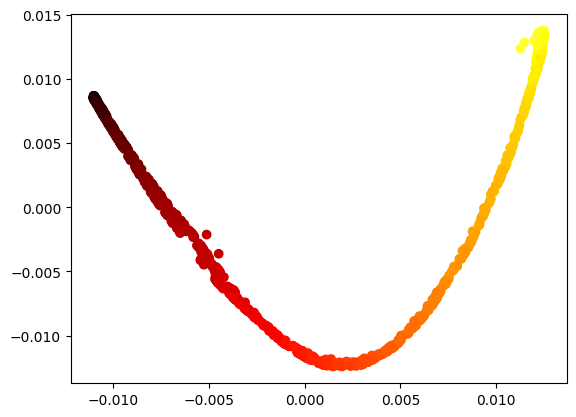

In [105]:
fig, ax = plt.subplots()
ax.scatter(Z[:,0], Z[:,1], c=t, cmap=darker_hot)

**Summary of Spectral embedding:**
- **so with spectral embedding - essentially what we're doing is using a set method (nearest neighbors using euclidean distance, rbf, correlation) we are defining the connectivity structure of the original dataset through a Laplacian matrix and then with the help of eigendecomposition producing a low dimensional representation - hence et voila -  our low dimensional representation of the original dataset**

- affinity:
  - how to build the similarity graph W. | is the most important parameter after n_components
    - k nearest neighbors graph - most common
     - se_knn = SpectralEmbedding(affinity='nearest_neighbors', n_neighbors=10)
    - RBF kernel - fully connected weighted graph
      - se_rbf = SpectralEmbedding(affinity='rbf', gamma=0.1)
    - or could use a precomputed technique.....
      - se_custom = SpectralEmbedding(affinity = 'precomputed')
      Z = se_custom.fit_transform(similarity_matrix)

    - nearest neighbors -> binary graph, connected or not. Simpler, faster, works well for clean structure
    - rbf -> weighted graph, all points connected with weights decaying by distance. Captures more nuanced similarity, sensitive to gamma
    - gamma -> only used with affinity='rbf'. controls rbf kernel width - same gamma as in kernel pca. small gamma = wide similarity neighborhoods... large gamma = narrow.
    - n_neighbots - only used with affinity='nearest_neighbors' same tradeoff as isomap's n_neighbors - too small disconnects graph and too large creates shortcuts 
     - k-nearest neighbors:
       - nxn matrix | sparse - most entries zero. | each row has at most k non-zero entries (j neighbors of that point)
    - rbf kernel: nxn dense.


**Define connectivity → encode it in the Laplacian → eigendecompose → coordinates fall out.**

passing precomputed correlation as a distance:
- key thing to remember is that - the 'precomputed' affinity in sklearn expects a **similarity matrix**, not a distance matrix
- **Correlation is a similarity** - (higher = more similar, range to -1 to 1). you can pass it directly as a precomputed distance but, you need to handle negative correlations as well..

In [106]:
# compute the correlation matrix...
C = np.corrcoef(X_swiss) # shape (nxn), values of [-1, 1]

In [107]:
C.shape

(1000, 1000)

the matrix expected (affinity) and the one used to compute the laplacian matrix ought to be of distances, i.e. shouldn't have any negative values within it...

In [110]:
# negative correlation = dissimilar, treat as no connection
C_clipped = np.clip(C, 0, 1)

# option 2- shift to (0,1) range
C_shifted = (C + 1)/2

# pass as precomputed affinity
se = SpectralEmbedding(
    n_components=2,
    affinity='precomputed',
    random_state=42
)
Z2 = se.fit_transform(C_clipped)

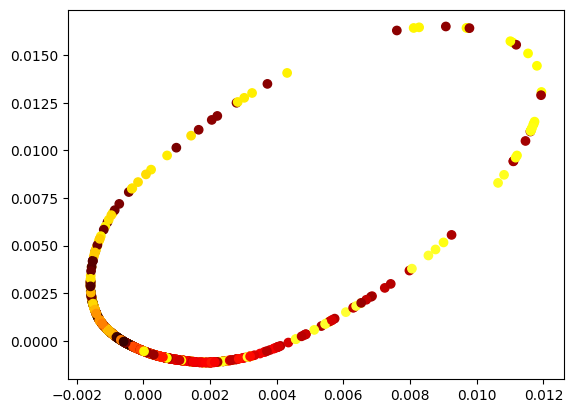

In [111]:
fig, ax = plt.subplots()
ax.scatter(Z2[:,0], Z2[:,1], c=t, cmap=darker_hot)

**TSNE:**
- **The core problem that t-sne is solving:**
  - Every method discussed so far: - isomap, spectral embedding, LLE, - builds a graph or distance matrix and finds coordinates that respect it. they all think in terms of distances, or connectivity. 
  - tsne thinks in terms of probabilities
  - the central question t-sne asks is:
    - if you picked a random neighbor for point i, whats the probability you'd pick point j
  - t-sne answers this question in high dimensional space, then finds a low dimensional embedding where those same probabilities are reproduced as faithfully as possible.

- Step 1 - Convert Distances to probabilities in high dimensional space
  - for each pair of points i and j, compute a conditional probability... P j|i => probability of j given i.....
  <img src="../../resource_images/Screenshot 2026-03-14 at 14.57.56.png"/>
  - This is a Gaussian centered on point i... points close to i get high probability - likely to be picked as neighbors. Points far from i get low probability - unlikely to be picked... the variance is different for every point. (crucial and we come back to this later)
  - Then symmetrize:
    - <img src="../../resource_images/Screenshot 2026-03-14 at 15.01.01.png"/>
  - now pij = pji - the probability is mutual...

    - The Perplexity parameter - how the variance is set...
    - the variance is not set manually, instead, you set the perplexity, and tsne finds the variance for each point that achieves that perplexity via binary search...
    - Perplexity is loosely:
        - <img src="../../resource_images/Screenshot 2026-03-14 at 15.03.18.png"/>
    - where H(Pi) is the shannon entropy of the probability distribution around point i. Intuitively, **perplexity controls the effecive number of neighbors that each point considers**
    - For example, a perplexity setting of 5 => each point considers approx 5 neighbors
    - Perplexity of 50  - each point considers approx 50 neighbors..
    - the standard deviation (sigma) adaptation is the key mechanism that handles varying density. In dense regions, sigma is small - you don't need to reach far to find neighbors, and in sparse regions, sigma is large and you need to reach further to find the same number of nieghbors..
    - tsne's adaptation is essentially doing the same thing as expanding the radius in sparse regions - but doing it in a principled probabilistic way that keeps the effective neighborhood size consistent, rather than just blindly connecting k ppints regardless of how far they are.

    - **Example:** Say u have 3 tight clusters of 100 points each, plus 5 isolated outlier points scattered far away...
        - fixed k = 10
        -  cluster points -> 10 neighbors all within the cluster
        - outlier points -> 10 neighbors pulled from distant clusters - outliers get falsely connected to the clusters
        
        - t-SNE perplexity = 10:
        - cluster points -> small standard dev - 10 effective neighbors all within cluster
        - outlier points -> large standard dev - probability mass spreads further but the soft probabilistic weighting means distant connections have genuinely low probability - outliers remain recognizably isolated..

        - nearest neighbor extraction, setting k versus setting perplexity for t-sne
        - fixed k = 10
            - find 10 nearest euclidean neighbors |
        - t-sne perplexity = 10
            - find the standard deviation (sigma) such that effective neighbor count is 10
        - in exteme cases all will perform the same mistakes....
        - this is where sigma adaption actually helps....
            - its specifically about **transitional boundary regions between dense and sparse areas within a connected structure**
            - consider this (Dense cluster) - Sparse bridge - Dense cluster
            - with fixed k=10
            - dense cluster points -> radius tiny, neighbors all within cluster
            - bridge points -> radius must expand hugely to find 10 neighors, pulls in points from both clusters simultaneously
            - bridge points get falsely connected to both clusters at once - corrupting the manifold structure...
            - with perplexity = 10
            - dense cluster points -> small sigma -> tight neighborhood
            - bridge points -> large sigma but probability mass spreads smoothly and proportionally
            - the soft weighting means bridge points aren't fully committed to either cluster - which is actually correct as they are genuinely in between
            - **Actual meaningful difference:** => with t-SNE's probabilistic approach - it allows partial membership. a point doesn't belong or not belong to a neighborhood - it belongs with a certain probability...
                - this matters because:
                - In k-NN (k- nearest neighbors), the kth neighbor and the (k+1)th neighbor are treated completely differently - one is in and one is out - even if they're almost equidistant.
                - In t-SNE, all points get a probability that smoothly decays with distance - no arbitrary cut off
                - for points near the k-NN cutoff boundary this soft assignment is more truthful. but for outlier sceenarios where the nearest neighbors are genuinely far away regardless - both approaches make the same mistake. the probabilistic mistake just expresses the mistake more gracefully

- **Step 2 - Define Probabilities in Low Dimensional Space:**
  - Now, you need corresponding probabilities in the low dimensional embedding. here tsne makes a deliberate choice - use a **Student's t-distribution** with 1 degree of freedom (Cauchy distribution) instead of a gaussian.
  - <img src="../../resource_images/Screenshot 2026-03-14 at 17.16.44.png"/>
  - why the student t-distribution over gaussian: the t-distribution has heavier tails than a gaussian. in the low dimensional space, to reproduce the same probability as the high dimensional gaussian, moderately distant points need to be pushed much further apart
  - This then creates a repulsive force that pushes dissimilar points far apart in the embedding. Without this, all moderately distant points would cluster near the center - the crowding problem that plagued original sne

- **Step 3 - Minimize KL Divergence:**
  - t-SNE finds embedding coordinates Z that make Q as similar to P as possible. It minimizes the KL divergence between P and Q:
  - <img src="../../resource_images/Screenshot 2026-03-15 at 09.38.30.png"/>
  - The KL divergence measures how different two probability distributions are. Minimizing it means making the low dimensional probability structure match the high dimensional one
  - This is solved by **gradient descent** - iteratively adjusting the positions of all n points in Z to reduce the KL divergence. 
  - This is why t-SNE is:
    - Stochastic: random initialization, gradient descent finds different local minima each run.
    - Slow - O(n**2) per iteration naively, O(nlogn) 
    - Has no closed form solution unllike PCA or spectral embedding
  - The Assymmetry of KL Divergence - critical for understanding t-SNE:
    - KL divergence is asymmetric - KL(P||Q) is not equal to KL(Q||P). This assymmetry explains t-SNE's characteristic behavior.
    - <img src="../../resource_images/Screenshot 2026-03-15 at 09.45.44.png"/>
    - When pij is large(points genuinely close in high dim) and qij is small (points far apart in low dim):
      - term = large x log(large/small) = very large penalty
    - When pij is small (points far apart in high dim) and qij is large (points close in low dim):
      - term = small x log(small/large) = small penalty (multiplied by small pij)
    - **Translation:** t-SNE is heavily penalized for placing nearby points far apart, but only lightly penalized for placing distant points close together.
      - This means that t-SNE **prioritizes local structure:** it will sacrifice global distance accuracy to preserve local neighborhood structure. two clusters that are far apart in high dimensional; space might end up close together in the t-SNE plot simply because the penalty for this error is small.
      - This is the mathematical root of t-SNE's global structure distortion

- **What t-SNE produces:**
  - for well-separated clusters, t-SNE produces good visuals...
  - intercluster distances are meaningless however, because whether cluster a appears far from cluster B or close to it in the plot is largely arbitrary - determined by the random initialization and gradient descent trajectory, not true high dim distances
  - The hyperparameters:
    - 
- **How t-sne handles points appearing in the neighborhood of more than one point** - since t-sne uses soft neighborhood assignment and not hard assignment as in isomap and spectral embedding:
  - say point x sits ambiguously between two clusters...
    <img src="../../resource_images/Screenshot 2026-03-15 at 10.10.22.png"/>
  - X has low but non-zero probability of being a neighbor of points in both cluster A and cluster B. In hard k-NN assignment X would be forcibly assigned to one side. t-Sne handles this gracefully through its probability framework.
  - **How t-SNE handles it - step by step:**
    - **Step 1: Asymmetric conditional probabilities:**
      - First t-SNE computes conditional probabilities from every point's perspective independently:
        - from cluster A point's perspective: 
          - <img src = "../../resource_images/Screenshot 2026-03-15 at 10.13.51.png"/>
        - from cluser B point's perspective:
          - <img src="../../resource_images/Screenshot 2026-03-15 at 10.14.51.png"/>
        - from X's perspective:
          - <img src="../../resource_images/Screenshot 2026-03-15 at 10.15.55.png"/>
        - note the assymmetry X considers A and B its neighbors but A and B don't strongly consider X their neighbor..
        - Why does this happen (cuz of the way conditional probability is computed..from the point in cluster A, we take into account all other closely knit points and then outlier...so its low). but from the outlier's pov, its got no closely knit points so its prob is going to be moderate in this case.
    - **Step 2 - Symmetrization resolves the asymmetry:**
     - <img src="../../resource_images/Screenshot 2026-03-15 at 10.38.37.png"/>
     - For the X-A relationship:
       - <img src="../../resource_images/Screenshot 2026-03-15 at 10.39.55.png"/>
     - for the X-B relationship:
       - <img src="../../resource_images/Screenshot 2026-03-15 at 10.41.00.png"/>
     - X ends up balanced, symmetric, low-moderate probability connections to both clusters. neigher cluster fully claims X, neither fully rejects it. this symmetrization averages out the directional disagreement.
    
    - **Step 3 - Normalization means all probabilities compete:**
     - The joint probability matrix P is normalized so all pij sum to 1 across the entire dataset:
       - <img src="../../resource_images/Screenshot 2026-03-15 at 10.44.24.png"/>
     - This means evert probability is defined relative to other probabilities globally. X's connections to A and B don't exist in isolation - they compete with all the strong within-cluster connections throughout the entire dataset
     - Strong within-cluster connections have pij. X's ambiguous cross-cluster connections have low pij. after normalization, X's cross-cluster connections are genuinely small relative to the dominant within-cluster structure.
    
     - **What this means for the embedding:**
      - During gradient descent, the forces on X come from all its probability connections simultaneously:
        - <img src="../../resource_images/Screenshot 2026-03-15 at 10.49.25.png"/>
      - Both cluters exert weak atteactive forces on X. The gradient descent finds the equilibrium position - X lands between the clusters, pulled weakly by both committed fully to neither..
      - Compare to hard k-NN where X would be forcibly assigned to whichever cluster contained its k-th nearest neighbor - a hard discountinuous decision...

- TSNE hyperparameters:
  - **perplexity:** most important parameter
    - controls the effective neighborhood size
    - typical range: 5 to 50
    - small perplexity: fine local structure - ignores global...
    - large perplexity: more global structure considered - clusters may merge
    - rule of thumb: start at 30, tune betweeen 5 and 50
    - must be less than n/3

  - **n_components:** - almost always 2 or 3
    - t-SNE is designed gor visualisation not dim reduction
    - using more than 3 components rarely makes sense

 - **n_iter:** - number pf gradient descent iterations
  - default 1000, often need 2000+ for large datasets.
  - more iterations -> better converged embedding.

 - **learning_rate** - gradient descent step_size
   - default 'auto' (=n/early_exaggeration)
   - too large -> points explode apart
   - too small -> points collapse to center

 - **early_exaggeration:** - multiplier on pij in early iterations
   - default 12 | temporarily exaggerates high dimensional probabilities -> forces tight initial cluster formation
   - reduces later to allow fine-grained adjustment

**1. What t-SNE actually optimises:**
 - t-sne converts pairwise distances into probabilities
   - <img src="../../resource_images/Screenshot 2026-03-15 at 11.19.07.png"/>

 - **Key Implication:**
   - This asymmetric KL divergence strongly penalises cases where:
     - **pij is large but qij is small**
   - Meaning:
    - if two points were close in the original space, the embedding must keep them close...
   - But, it does not strongly penalise:
    - small pij becoming a large qij
    - Meaning: Points that were far apart can end up close together without much penalty

**2. Consequence: Local structure is preserved, global structure is not**
 - Because of that asymmetry:
   - **Local neighborhoods are preserved very strongly**
   - **Global geometry can distort freely**
 - So, things like:
   - distance between clusters: distorts global distances..
   - cluster sizes: could have dense or spread out clusters ending up as tight balls or wide balls | so the visual area of the cluster is misleading.. this happens because t-sne focuses on preserving neighbor probabilities and does not preserve density or scale, also the algorithm tends to equalise cluster sizes visually..
     - does it assign points to wrong clusters: usually no because of how KL divergence works... if its in a wrong cluster then the KL divergence error is high as pij will be high and qij small....

   - relative placement of clusters..
 
 - Kind of errors that usually happen with t-sne:
   - When true neighbors stay together, t-sne may:
     - **Create artificial gaps between clusters:**
       - clusters can look much more separated than they really are..
     - **Split one cluster into multiple islands:**
       - a single continuous structure may appear as several clusters
         - low perplexity settings being one of the reasons why this happens
         - perplexity in t-sne is essentially the effective number of neighbors each point considers:
           - typical values: 5 (very local) | 30 - standard | 50+ - more global
         - low perplexity means:
           - points only care about very close neighbors
         - low perplexity will produce multiple clusters (splitting the main ones) - whilst keeping the kl divergence low
       - why the objective function allows this:
         - t-SNE minimizes the KL divergence which strongly penalises losing true neighbors but barely penalises breaking global continuity
       - another reason: the repulsive forces:
         - t-SNE uses a student-t distribution in the low dimensional space
         - this creates a strong repulsive force between groups of points
         - so once a small gap forms during optimization, the repulsion tends to amplify it...

**3 - why this makes tsne great for visualisation:**
 - for visualisation you mainly want:
   - clusters to appear clearly separated
   - local neighborhoods preserved
   - outliers visible
 - t-sne excels at this because:
   - it aggresively separates groups
   - spreads clusters out
   - makes structure visually interpretable
   - This is also helped by the **student t- distribution** which creates string repulsion between distant points..

**4 - why its bad for general dimensionality reduction:**
 - for downstream tasks you want the embedding to preserve meaningful geometry
 - for example:
   - clustering algorithms rely on distances
   - classifiers rely on geometry
   - regression relies on relationships between points
 - t-sne breaks these assumptions because:
   - **Global distances are meaningless:** cluster spacing is not trustworthy
   - **Cluster sizes are distorted:** 
   - **It is non-parametric:** You cannot easily embed new points without recomputing the model.
 - it is stochastic: due to random initialization and changes in the geometry

**t-sne's asymmetric KL divergence strongly penalises breaking local neighborhood relationships, but barely penalises creating false enighbors, allowing the global structure to distort**

In [112]:
from sklearn.manifold import TSNE

In [113]:
t_ = TSNE()

In [114]:
Z = t_.fit_transform(X_swiss)

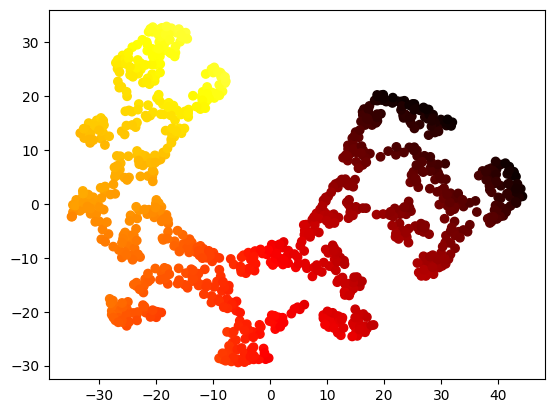

In [115]:
fig, ax = plt.subplots()
ax.scatter(Z[:,0], Z[:,1], c=t, cmap=darker_hot)

**UMAP:**
- Every method considered so far starts from a geometric or statistical intuition:
  - MDS: preserve distances
  - Spectral: preserve graph connectivity
  - t-SNE: preserve neighborhood probabilities
- UMAP starts from **topology** - the mathematical study of the shape of spaces, independent of distances or coordinates
- The question UMAP asks is:
  - **What is the topological shape of the manifold your data lives on, and how do you find a low dimensional representation with the same topological shape**
- The practical implementation comes down to building a better graph than anyone else and optimizing a better objective than KL divergence. But the topological foundation is what gives UMAP its theoretical justification and practical superiority

- **The Three Phases:**
  - **Phase 1 - Build a fuzzy Topological Representation**
    - Step 1A - Local Metric Adaptation:
      - for each point i, find its k-nearest neighbors. then compute the distance to the nearest neighbors specifically:
        - <img src="../../resource_images/Screenshot 2026-03-16 at 05.28.34.png"/>
      - This pi is subtracted from all distances from point i:
        - <img src="../../resource_images/Screenshot 2026-03-16 at 05.29.53.png"/>
      - **why subtract pi** - this ensures every point has at least one neighbor at distance zero - guaranteed connectivity regardless of how isolated the point is. this local metric makes the space locally uniform - from every point's perspective, its nearest neighbor is always at distance zero, so no point is more isolated than any other in its own local frame.
    - Step 1B - Compute edge weights:
      - For each neighbor j of point i, compute a fuzzy membership weight:
        - <img src="../../resource_images/Screenshot 2026-03-16 at 05.34.02.png"/>
      - Where the standard deviation, is found by binary search to satisfy:
        - <img src="../../resource_images/Screenshot 2026-03-16 at 05.35.38.png"/>
        - looks similar to t-sne's gaussian probabilities but with a crucial difference - w(i,j) is bounded between 0 and 1 and represents **fuzzy set membership** Point j either fully belongs to i's neighborhood (w=1), partially belongs (0 < w < 1), or doesn't belong (w approx to zero)
    - Step 1C - Symmetrize with fuzzy union:
      - t-SNE symmetrizes by averaging: p_{ij} = (p_{j|i} + p{i|j})/2n
      - UMAP symmetrizes using **fuzzy set union:**
        - w(i,j) = w(i -> j) + w(j -> i) - w(i -> j)xw(j -> i)
        - this is the probability union formula P(AuB) = P(A) + P(B) - P(AnB)
      - why union and not average:
        - average t-sne: if i considers j a neighbor but j doesn't consider i a neighbor, the relationship gets averaged down - weakened
        - union (UMAP): if either i considers j a neighbor or j considers i a neighbor, the relationship is preserved - strengthened. the cpnnection exists if either direction supports it...
        - means that UMAP's graph is **denser and more connected** than t-sne's probability matrix. more connections survive, especially in sparse regions where one0directional neighbor relationships are common
        - this is the fuzzy topological graph - a weighted graph where the edge weights represent the strength of the topological connection between points..
  - **Phase 2 - Construct Low Dimensional Representation:**
    - UMAP initilizes the low dimensional embedding using spectral embedding on the fuzzy graph - not random initialization like t-SNE. this is a major practical advantage:
      - Spectral initialization is deterministic
      - Already approximately correct before optimization begins
      - Much faster convergence
      - Less susceptible to initialization-dependent local minima
    - This is why UMAP is dramatically faster than t-sne and more reproducible

 - **Phase 3 - Optimize the embedding:**
   - UMAP optimizes a cross-entropy loss between the high dimensional fuzzy graph and the low dimensional fuzzy graph..
   - <img src="../../resource_images/Screenshot 2026-03-16 at 06.08.29.png"/>
   - where v(i,j) is the low dimensional fuzzy membership:
     - <img src="../../resource_images/Screenshot 2026-03-16 at 06.10.41.png"/>
   - Parameters a and b are fit to the 'min_dist' hyperparameter - controlling how tightly points are packed.
   - **This loss has two terms:**
     - **Attractive term** (left most part of the loss)
       - for edges with a high w_{ij} (true neighbors) - pulls them together in low dimension
       - equivalent to t-sne's attractive force
     - **Repulsive term** (right most part of the loss)
       - for non edges (1-w_{ij} approx to 1) - pushes non-neighbors apart
       - this is what t-sne lacks for global structure
       - explicitly optimises where non-neighboring points land
   - This second term is the key difference from t-sne's KL divergence - UMAP has an explicit repulsive loss that acts on all **non-neighboring pairs** and not just local neighborhoods
   - <img src="../../resource_images/Screenshot 2026-03-16 at 06.18.13.png"/>
   - UMAP's cross entropy loss has an attractive and repulsive term
     - the repulsive term explicitly contributes for all non-neighboring pairs. non-neighbors get pushed apart proportional to how close they currently are - this directly encodes global separation into the loss function
     - The balance between attraction and repulsion is controlled by n_epochs and the learning rate - UMAP can tune how much global vs local structure is preserved.
   - **The Key-Hyperparameters:**
     - **n_neighbors** - same role as k in spectral/isomap but more robust
       - controls the size of the local neighborhood used to build the fuzzy graph**
       - small n_neighbors (2-5) -> very local structure - fine grained details but ignores globa;
       - large n_neighbors (50-200) -> broader struct, more global, smoother embeddings
       - default 15

**Limitation: UMAP repels non -neighbors - so better than t-SNE at this in that in makes an effort to preserve the global struct, but it simply repels them, but doesn't encode their true distances**

**What UMAP actually tries to preserve**
 - UMAP builds a **k-nearest graph** in high dimensional space
 - information it keeps is essentially:
   - "who is connected to whom locally"
 - it doesn't store exact long-distance relationships
- **UMAP's repulsive term**
  - umap's loss roughly encourages:
    - neighbors -> move closer
    - non-neighbors -> don't overlap
  - the repulsion is uniform, not proportional to real distance
  - two points that were very far apart or were moderately far apart receive similar repulsive treatment

**Key points umap:**
- In umap we do:
  - find the k-nearest neighbors for each point using the euclidean distances, then normalise the distances using:
    - <img src="../../resource_images/Screenshot 2026-03-19 at 09.59.02.png"/>
  - Distances are not comparable across different regions in the space....(nearest neighbor ditances are tiny in dense spaces, and large in sparse spaces) | without correction: sparse regions look artificially apart and dense regions would dominate the structure...
  - umap is trying to preserve the topology, not the metric structure (so trying to preserve who is connected to whom but not exact distances or densities)
  - problem with raw distances:
    - dense region: Distances: 0.01, 0.02, 0.03 | cuz there's many points packed tightly
    - sparse region: distances: 5,6,7 | just fewer samples
    - key insight: these might be the same underlying manifold, but just sampled differently
  - without correction: if you use raw distances directly:
    - sparse regions will fall apart: 
      - because distances are large -> similarity is close to zero
      - graph becomes weakly connected or disconnected (cuz of the large distances, probabilities of these points connecting will be close to zero and these sparse regions would fall apart or disappear in the low dimensional representation)
    - algorithm thinks: these points aren't really connected... even though they are
  - dense regions dominate optimization:
    - because:
      - many small distances -> strong attractive forces
      - many edges (high weight in the loss)
    - so, the embedding prioritises : fitting dense clusters perfectly, and ignoring sparse regions
  - sampling density is not equal to true geometry:
    - key philosophical point: density often reflects how data was sampled, not the true shape of the manifold
    - examples: more customers in cities than rural areas | more images of common objects than rare ones | sensor noise/bias
    - if you preserve density directly, you are preserving sampling bias, not structure.
  - should dense regions dominate:

  - **Trade off introduced by umap's scaling**
     - you lose true density information (looks like a cluster but is not actually a cluster)
     - absolute distance meaning
     - faithful representation of cluster sizes...

     - umap optimises who is connected to whom locally and not preserve true global geometry or density.. because of that it sometimes can turn a continious structure into visually separated clusters
     - density normalization breaks continuity - sparse regions get compressed | dense regions get expanded 
     - if you have a smooth gradient in data density:
       - weak connections get dropped

**UMAP pipeline (anchor)**
- k-nn graph (choose n_neighbors)
- distance scaling (pi, sigma_i)
- asymmetric probabilities (pj|i)
- symmetrization (pij)
- low-d similarity (heavy tail) (qij)
- loss optimization (cross-entropy)

- **STRENGTHS**
  - Preserves local neighborhood structure well...(cuz of using knn and the loss penalizes nearby pairs if they are put far apart)
  - Works well with non-uniform density data (through umap scaling techniques of ensuring the distances are scaled equally - by subtracting by pi - this ensures all distance probabilities are on the same scale)
  - good global structure (better than t-sne) - (cuz of symmetrization, heavy-tailed qij, explicit repulsion term)
    - non-neighbors are explicitly modeled, repulsion exists across many distances
    - prevents total collapse into blobs
  - scales well to large datasets
    - comes from: approximate k-nn graphs, sparse graph representations
  - produces visually interpretable embeddings (strong repulsion term | heavy tailed similarity)

- **WEAKNESSES**
  - Distorts global distances
    - comes from: distance scaling (pi, and sigma i) | loss ignores exact distances as well
  - Destroys density information:
    - forces each point to have ~k neighbors | equalizes local structure..
    - dense v sparse regions local similar
  - can create fake clusters (limited knn graph, local scaling, heavy tails, repulsion)
  - can break continuous manifolds (optimization trade offs, k-nn graph finite neighbors)
  - sensitive to hyperparameters (n_neighbors, min_dist)

**UMAP: a graph of important neighbor relationships** 

UMAP hyperparameters:
- n_neighbors: controls the size of the local neighborhood used to build the graph | high n_neighbors lowers the expansiion limitation tries to preserve global approximation better but at the risk of losing vital local information and distorting the local structure
  - n_neighbors: for each point, it finds the k nearest neighbors and computes the local connectivity probabilities
  - (5-15): very local structure, many small clusters, noisy
  - (50-200): more global structure, smoother/merged structure (loss of local info), stable
  - controls local vs global trade-off

- min_dist 
  - controls **how close points are allowed to get in the LOW-DIMENSIONAL embedding**
  - UMAP is trying to preserve neighbor relationships using an attraction function | min_dist defines the distance below which points are no longer strongly pulled together. So: if 2 points are neighbors -> they are pulled together, but they won't collapse closer than roughly min_dist....
  - effect in practice:
    - small min_dist (0.0 to 0.1): points can get very close
    - clusters become tight and dense
    - large min_dist (0.5 to 1.0): points stay apart | embedding looks more spreadout and continuous
  - if 2 points are very close in the original space, they might not end up superclose in the embedding space if min_dist is large
  - neighbor selection = input space distances
  - min_dist = output space spacing constraint

- n_components:
  - controls the dimensionality of the output space
  - 2 -> visualisation
  - 10-100 -> downstream ML
  - Higher = more faithful, lowe = more visual

- metric:
  - distance function used to find neighbors | common choices: euclidean, cosine, manhattan, correlation
  - umap's entire graph depends on it | bad metric = wrong neighborhoods = bad embedding

- spread:
  - controls the overall scale of embedding | works close with min_dist | effect: larger -> points spread further apart, smaller -> more compact embedding

- set_op_mix_ratio:

- local connectivity: minimum number of neighbors that are guaranteed connected

- repulsion_strength
- n_epochs: number of optimization iterations

Key Differences:
- High dimensional representation: tsne => Probabilities (Gaussian) | umap => Fuzzy graph (topological)
- Low-dimensional representation: tsne => student-t probabilities | umap => fuzzy graph
- Objective: tsne => KL divergence | umap => cross entropy
- Philosophy: tsne => match similarities | umap => preserve manifold structure

  - TSNE v. UMAP high dimensional side:
    - t-sne: uses a gaussian kernel | converts distances to probabilities | uses perplexity to control neighborhood size
      - each point has a soft neighborhood of ~ k neighbors
    - umap: builds a k-nearest neighbor graph
      - then assigns edge weights (fuzzy membership strengths)
      - 
   - TSNE uses KL divergence, which has a strong penalty if true neighbors are missed and a weak penalty if false neighbors are created. 
   - 

   - TSNE strengths:
     - extremely good local clustering, very clear visual separation
   - TSNE weaknesses:
     - fake clusters can appear, global structure is destroyed, distances are meaningless

   - UMAP strengths:
     - better global structure preservation | more faithful topology | faster and scalable | can be used beyond visualisation
   - UMAP weaknesses:
     - still distorts density | can break continuous manifolds (repulsion force) | sensitive to hyperparameters

  - density handling (subtle but important):
    - t-sne uses adaptive bandwidth (sigma) | normalises density
    - dense and sparse regions look similar in size

  - umap also does local normalization but preserves more relative structure | still distorts density but is less aggressive

- Failure modes:
  - TSNE: fake clusters (due to weak penalty on false neighbors) | cluster spacing is meaningless (distances between clusters are not real) | uniform cluster sizes (density wiped out)

   - UMAP failure modes: Manifold tearing (graph construction can disconnect regions - uses repulsive force in its entropy loss which is capable of repulsing/breaking apart weakly connected joints, joining clusters to result in multiple splits....) | over compression: some regions collapse too tightly | hyperparameter sensitivity: n_neighbors, min_dist... heavily affect results

- **When does either have the upper hand?**
    - use tsne for clean, separated clusters for visualisation
    - you care about local grouping only
    - dataset is moderate size

    - use umap when: you care about some global structure | you want scalability | you might resuse embedding downstream

- TSNE: don't lose true neighbors: don't care if you invent some | 
- UMAP: preserve the graph structure - don't invent or destroy connections

- tsne is a viz tool that exaggerates local strucuture | umap is a manifold learning method that tries to preserve structure more faithfully

In [116]:
import umap

ModuleNotFoundError: No module named 'umap'